In [ ]:
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import learnQ as lq


# Toy Examples

The treated unit covariates are not in the convex hull of the donor units. $Q$ modifies the donor units covariates to find a combination whose convex hull contains the donor unit.

With 2 outcomes and 2 donors, it is possible to embed into 2 dimensions and find an optimal solution. Does this work with (3, 3, 3)?

There are:  2  weights being estimated
LearnQ prediction:  [1. 1.]
Simplex Constraint pred:  [0.5 0.5]
Truth:  [1. 1.]
Original Covariates: 
 [[1. 0.]
 [0. 1.]]
Q_final: 
 [[-0.142  2.142]
 [ 1.287  0.713]]
Synthetic Covariates: 
 [[-0.14231309  2.14231574]
 [ 1.28659445  0.71340488]]
w_final: 
 [0.5 0.5]


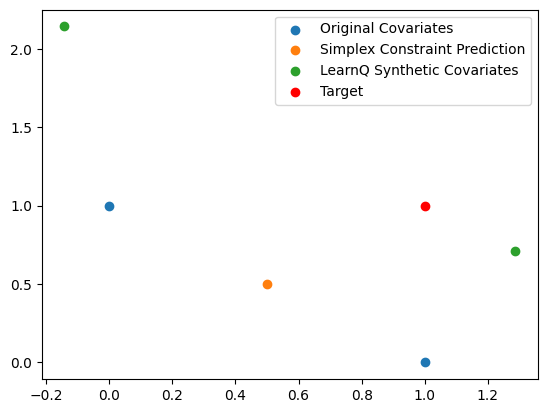

In [68]:
torch.manual_seed(215)
import matplotlib.pyplot as plt

# Target and Covariates
d_1 = torch.tensor([1.0, 1.0], dtype=torch.float64)
Y_1 = torch.tensor([[1.0, 0.0], [0.0, 1.0]], dtype=torch.float64)
target_vectors = [d_1]
covariate_matrices = [Y_1]

# LearnQ optimization
Q_final, w_final = lq.learnQ(target_vectors, covariate_matrices, 2, 5000, 0, 1, False)

# Optimization over the simplex
target = d_1
covariates = Y_1
N_minus_1 = covariates.shape[1]
print("There are ",N_minus_1," weights being estimated")
w = cp.Variable(N_minus_1, nonneg=True) # Enforces w >= 0
constraints = [cp.sum(w) == 1]
obj = cp.Minimize(sum(cp.sum_squares(target - covariates @ w)))
prob = cp.Problem(obj, constraints)
prob.solve()

# Results
synth_covariates = (covariates @ Q_final).squeeze().numpy()
simplex_constraint_pred = (covariates @ w.value).detach().numpy().round(3)
print("LearnQ prediction: ", (covariates @ Q_final @ w_final).detach().numpy().round(3))
print("Simplex Constraint pred: ", simplex_constraint_pred)
print("Truth: ", target.numpy().round(3))
print("Original Covariates: \n", covariates.numpy().round(3))
print("Q_final: \n", Q_final.squeeze().round(3))
print("Synthetic Covariates: \n", synth_covariates)
print("w_final: \n", w_final.round(3))

# Plot
plt.scatter(Y_1[:, 0], Y_1[:, 1], label='Original Covariates')
plt.scatter(simplex_constraint_pred[0].item(), simplex_constraint_pred[1].item(), label='Simplex Constraint Prediction')
plt.scatter(synth_covariates[:, 0], synth_covariates[:, 1], label='LearnQ Synthetic Covariates')
plt.scatter(target[0].item(), target[1].item(), color='red', label='Target')
plt.legend()
plt.show()

Yes, we are able to find a perfect embedding in the cases (3,3,3) - (10,10,10).

In [ ]:
torch.manual_seed(215)
import matplotlib.pyplot as plt

# Target and Covariates
d_1 = torch.ones(10, dtype=torch.float64)
Y_1 = torch.eye(10, dtype=torch.float64) # identity matrix
target_vectors = [d_1]
covariate_matrices = [Y_1]

# LearnQ optimization
Q_final, w_final = lq.learnQ(target_vectors, covariate_matrices, 10, 5000, 0, 1, False)

# Optimization over the simplex
target = d_1
covariates = Y_1
N_minus_1 = covariates.shape[1]
print("There are ",N_minus_1," weights being estimated")
w = cp.Variable(N_minus_1, nonneg=True) # Enforces w >= 0
constraints = [cp.sum(w) == 1]
obj = cp.Minimize(sum(cp.sum_squares(target - covariates @ w)))
prob = cp.Problem(obj, constraints)
prob.solve()

# Results
synth_covariates = (covariates @ Q_final).squeeze().numpy()
simplex_constraint_pred = (covariates @ w.value).detach().numpy().round(3)
print("LearnQ prediction: ", (covariates @ Q_final @ w_final).detach().numpy().round(3))
print("Simplex Constraint pred: ", simplex_constraint_pred)
print("Truth: ", target.numpy().round(3))
print("Original Covariates: \n", covariates.numpy().round(3))
print("Q_final: \n", Q_final.squeeze().round(3))
print("Synthetic Covariates: \n", synth_covariates)
print("w_final: \n", w_final.round(3))



There are  10  weights being estimated
LearnQ prediction:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Simplex Constraint pred:  [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Truth:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Original Covariates: 
 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Q_final: 
 [[ 1.847  0.813 -0.598  1.701  2.852  0.805  1.836 -0.007  0.159  0.593]
 [ 0.544  1.085  0.313  0.637  0.296 -1.085  2.508  2.522  2.101  1.079]
 [ 0.503  0.858  0.593  1.387  1.8    0.305  1.167  1.231  0.936  1.222]
 [ 1.109  0.343  1.787  2.187  2.14   0.174  1.537  0.331  0.014  0.378]
 [ 0.682  0.092 -0.073  2.105  0.886  2.351  0.838  1.742 -0.964  2.341]
 [ 0.75   1.476 -0.975  0.554  0.959  1.275  1.234  1.236 -0.146  3.637

# Psuedo Inverses

### Single training example

In [461]:
d_1 = torch.tensor([6.0, 2.0], dtype=torch.float64)
Y_1 = torch.tensor([[2.0, 4.0, 1, 9], [3.0, 5.0, 10, 11]], dtype=torch.float64)

target_vectors = [d_1]
covariate_matrices = [Y_1]

Q_final, w_final = learnQ(target_vectors, covariate_matrices, 4, False)

# make sense that these would be the same, because in the last step of the 
# algorithm, we learn the optimal w for the given Q.
# and this is given by the psuedo-inverse
# maybe this means we don't have to have one of the differentiation
# steps - can just use the pseudo-inverse instead of gradient descent on w.
pinv = torch.linalg.pinv(Y_1@ Q_final)
print("\noptimal w using psuedo inverse: \n", pinv@d_1)
print("optimal w using algorithm: \n", w_final.round(2))

Step    0 | Loss: 184.58965332
Step  200 | Loss: 0.75188195
Step  400 | Loss: 0.65810330
Step  600 | Loss: 0.64516704
Step  800 | Loss: 0.64113552
Step 1000 | Loss: 0.63839181
Step 1200 | Loss: 0.63697609
Step 1400 | Loss: 0.63517967
Step 1600 | Loss: 0.63370632
Step 1800 | Loss: 0.63263990

optimal w using psuedo inverse: 
 tensor([0.17, 0.36, 0.33, 0.13], dtype=torch.float64)
optimal w using algorithm: 
 [0.17 0.35 0.34 0.14]


## Multiple training examples

Pseudo inverse still shows up.

In [462]:
# Data More donors than time points.
d_1 = torch.tensor([6.0, 2.0], dtype=torch.float64)
Y_1 = torch.tensor([[2.0, 4.0, 1, 9], [3.0, 5.0, 10, 11]], dtype=torch.float64)

d_2 = torch.tensor([5.0, 3.0], dtype=torch.float64)
Y_2 = torch.tensor([[1.0, 2.0, 3, 12], [4.0, 6.0, 5, 7]], dtype=torch.float64)

target_vectors = [d_1, d_2]
covariate_matrices = [Y_1,Y_2]

Q_final, w_final = learnQ(target_vectors, covariate_matrices, 5, False)

# very similar - but does this hold inside the loop?
print("mean of psuedo-inverses: \n", ((torch.linalg.pinv(Y_1@Q_final) @ d_1) + (torch.linalg.pinv(Y_2@Q_final) @ d_2)) / 2)

print(w_final.round(2))

Step    0 | Loss: 74.09506824
Step  200 | Loss: 1.68906200
Step  400 | Loss: 1.14762923
Step  600 | Loss: 0.99151832
Step  800 | Loss: 0.95811428
Step 1000 | Loss: 0.94108430
Step 1200 | Loss: 0.93349423
Step 1400 | Loss: 0.92581964
Step 1600 | Loss: 0.91995205
Step 1800 | Loss: 0.91576849
mean of psuedo-inverses: 
 tensor([ 0.43, -0.00,  0.27,  0.07,  0.19], dtype=torch.float64)
[ 0.44 -0.    0.29  0.03  0.24]
